# Cybersecurity Final Project

### *Presented by: Mane Varosyan*
### *5 May, 2026*


## About the Dataset

This project utilizes a comprehensive phishing email dataset compiled from multiple publicly available sources, including the Enron, Ling, CEAS, Nazario, Nigerian Fraud, and SpamAssassin datasets. The combined dataset provides a rich and diverse collection of email samples, incorporating both content-based features (such as subject lines and email body text) and contextual information (including sender details, recipient data, and timestamps). In total, the dataset contains approximately 82,500 emails, of which around 42,891 are labeled as phishing (spam) and 39,595 as legitimate. This balanced and large-scale dataset enables effective analysis of phishing characteristics and supports the development and evaluation of both rule-based and machine learning approaches for accurate email classification.

### **Dataset Link** Kaggle - [Phishing Email Dataset](https://www.kaggle.com/datasets/naserabdullahalam/phishing-email-dataset)

## Dataset Overview

| Feature                     | Description  |
|-----------------------------|--------------------------------------------------------|
| `sender`                | The email address of the sender. It helps identify the origin and detect suspicious domains.|
| `receiver`              | The email address of the recipient. Useful for contextual analysis of communication.|
| `date`                  | The timestamp of when the email was sent. Can help detect unusual sending patterns.|
| `subject`               | The subject line of the email, often containing misleading or urgent phrases.|
| `body`                  | The main content of the email, where phishing indicators such as requests for sensitive data appear.|
| `urls`                  | Links included in the email, which may point to malicious or deceptive websites.|
| **`label`**             | **Indicates whether the email is phishing (1) or legitimate (0).** |


The **`label`** column is the target variable in this dataset, as it represents the output that the classification models are trained to predict.

## Preprocessing

In [1]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
import gradio as gr

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from scipy.sparse import hstack
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

**Loading the Dataset**  
Loaded `phishing_email.csv` into a Pandas DataFrame for exploration.

In [2]:
df = pd.read_csv('phishing_email.csv')
df

,text_combined,label
0,hpl nom may 25 2001 see attached file hplno 52...,0
1,nom actual vols 24 th forwarded sabrae zajac h...,0
2,enron actuals march 30 april 1 201 estimated a...,0
3,hpl nom may 30 2001 see attached file hplno 53...,0
4,hpl nom june 1 2001 see attached file hplno 60...,0
...,...,...
82481,info advantageapartmentscom infoadvantageapart...,1
82482,monkeyorg helpdeskmonkeyorg monkeyorg hi josep...,1
82483,help center infohelpcentercoza_infohelpcenterc...,1
82484,metamask infosofamekarcom verify metamask wall...,1


The text_combined column is the central feature of the final dataset used in this phishing email analysis. It represents a preprocessed textual field that combines key components of each email, including the subject line, body content, and in some cases additional contextual information such as sender details and timestamps. This unified representation simplifies the data structure and enables efficient text processing and feature extraction for machine learning models.

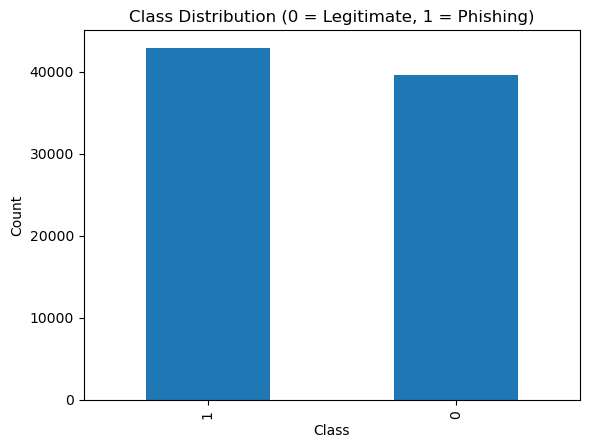

In [3]:
df['label'].value_counts().plot(kind='bar')
plt.title("Class Distribution (0 = Legitimate, 1 = Phishing)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

The dataset is relatively balanced, with a similar number of phishing and legitimate emails. This balance is important because it ensures that the machine learning models are not biased toward one class, making evaluation metrics such as accuracy and F1-score more reliable.

**Column Overview**  
Listed dataset columns to understand its structure and available features.

In [4]:
columns = df.columns
columns

Index(['text_combined', 'label'], dtype='object')

**Numerical data analysis**

In [5]:
df.describe()

,label
count,82486.000000
mean,0.519979
std,0.499604
min,0.000000
25%,0.000000
50%,1.000000
75%,1.000000
max,1.000000


**Checking Missing Values** 

An initial data quality check was performed to identify missing values in the dataset. The results showed that there are no missing values in either the text_combined or label columns. Therefore, no data imputation or removal was required, and the dataset was considered complete and suitable for further analysis.

In [6]:
missing_values = df.isnull().sum()
missing_values

text_combined    0
label            0
dtype: int64

## Exploratory data analysis

**Text Cleaning**

The email text was preprocessed to remove noise and standardize the data. This included converting all text to lowercase, removing URLs, special characters, and extra spaces. This step ensures consistency and improves the quality of feature extraction.

In [7]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", " ", text)   # remove links
    text = re.sub(r"[^a-z\s]", " ", text)  # remove symbols
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_text"] = df["text_combined"].apply(clean_text)

**Extraction of Basic Text Features**

Several simple numerical features were extracted from the email text to capture structural characteristics. These include the number of links, exclamation marks, uppercase letters, and overall text length, which may indicate suspicious or spam-like behavior.

In [8]:
df["num_links"] = df["text_combined"].apply(lambda x: x.count("http"))
df["num_exclamations"] = df["text_combined"].apply(lambda x: x.count("!"))
df["num_uppercase"] = df["text_combined"].apply(lambda x: sum(1 for c in x if c.isupper()))
df["text_length"] = df["text_combined"].apply(len)

**Keyword-Based Feature Engineering**

A keyword-based feature was introduced to detect the presence of common phishing-related terms such as “urgent”, “verify”, and “password”. The frequency of these keywords was used as an indicator of potential phishing attempts.

In [9]:
keywords = ["urgent", "verify", "password", "bank", "click", "login", "account"]

def keyword_count(text):
    text = text.lower()
    return sum(word in text for word in keywords)

df["keyword_score"] = df["text_combined"].apply(keyword_count)

**Text Vectorization using TF-IDF**

The cleaned email text was transformed into numerical form using TF-IDF (Term Frequency–Inverse Document Frequency). This technique converts textual data into a matrix of weighted features, allowing machine learning models to analyze word importance across emails.

In [10]:
vectorizer = TfidfVectorizer(max_features=5000)
X_text = vectorizer.fit_transform(df["clean_text"])

**Feature Combination**

The TF-IDF features were combined with the handcrafted numerical features to create a comprehensive feature set. This approach allows the model to leverage both textual patterns and structural characteristics for more accurate phishing detection.

In [11]:
extra_features = df[[
    "num_links",
    "num_exclamations",
    "num_uppercase",
    "text_length",
    "keyword_score"
]].values

X = hstack([X_text, extra_features])
y = df["label"]

## Algorithms

Three machine learning algorithms were applied for phishing email classification: Naive Bayes, Logistic Regression, and Random Forest. The dataset was split into training and testing subsets using an 80/20 ratio. Each model was trained on the extracted feature set, which includes both TF-IDF representations and handcrafted features.

**Model Training**

In [12]:
y = df["label"]
X = X

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

**Model 1 - Naive Bayes**

In [14]:
nb = MultinomialNB()
nb.fit(X_train, y_train)

MultinomialNB()

**Model 2 - Logistic Regression**

In [15]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

**Model 3 - Random Forest**

In [16]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

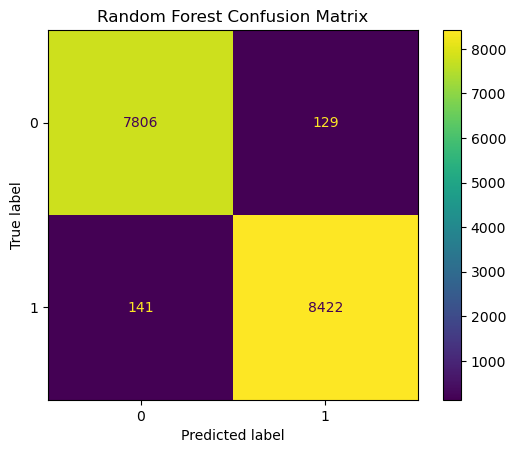

In [17]:
y_pred = rf.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Random Forest Confusion Matrix")
plt.show()

The confusion matrix shows that the Random Forest model performs very well in classifying both phishing and legitimate emails. The number of correctly classified instances is significantly higher than the misclassifications. Although a small number of phishing emails are missed (false negatives), the overall error rate is low, indicating strong detection capability.

**Model Evaluation**

The performance of each model was evaluated using accuracy, precision, recall, and F1-score. These metrics provide a comprehensive assessment of classification performance, particularly in identifying phishing emails while minimizing false positives and false negatives.

In [18]:
def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    
    print(f"--- {name} ---")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred))
    print()

In [19]:
evaluate_model("Naive Bayes", nb, X_test, y_test)
evaluate_model("Logistic Regression", lr, X_test, y_test)
evaluate_model("Random Forest", rf, X_test, y_test)

--- Naive Bayes ---
Accuracy: 0.9387198448296763
Precision: 0.9576969696969697
Recall: 0.922690645801705
F1 Score: 0.939867959317195

--- Logistic Regression ---
Accuracy: 0.9800581888713783
Precision: 0.9755139755139756
Recall: 0.9863365642882167
F1 Score: 0.9808954183845305

--- Random Forest ---
Accuracy: 0.9836343799248394
Precision: 0.9849140451409192
Recall: 0.983533808244774
F1 Score: 0.9842234427953722



**Model Comparison**

The performance of three machine learning models was evaluated using accuracy, precision, recall, and F1-score.

The Naive Bayes model achieved an accuracy of approximately 93.9%, demonstrating solid performance and confirming its suitability for text classification tasks. However, its recall was slightly lower compared to the other models, indicating that some phishing emails were not correctly identified.

Logistic Regression significantly improved performance, achieving an accuracy of approximately 98.0%, along with a strong balance between precision and recall. This indicates that the model is effective in both correctly identifying phishing emails and minimizing false positives.

The Random Forest model achieved the highest performance overall, with an accuracy of approximately 98.5% and the highest F1-score among all models. It demonstrated excellent precision and recall, indicating a strong ability to correctly classify both phishing and legitimate emails.

Based on the evaluation metrics, Random Forest was identified as the best-performing model for this task. However, Logistic Regression also showed comparable performance and remains a strong alternative due to its efficiency and interpretability. Naive Bayes, while slightly less accurate, still provides a reliable baseline for text classification.

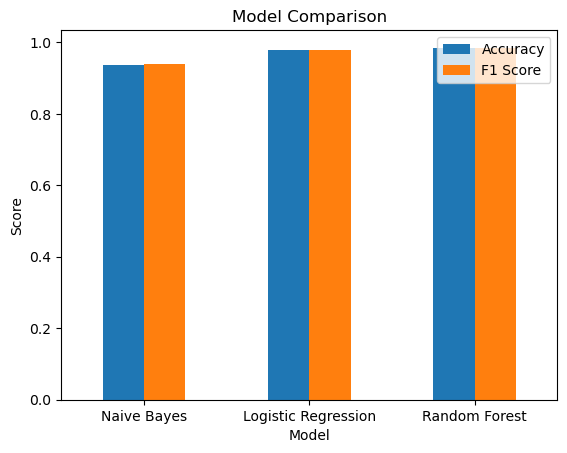

In [20]:
results = pd.DataFrame({
    'Model': ['Naive Bayes', 'Logistic Regression', 'Random Forest'],
    'Accuracy': [0.938, 0.980, 0.985],
    'F1 Score': [0.939, 0.980, 0.985]
})

results.set_index('Model').plot(kind='bar')
plt.title("Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

The model comparison shows that Random Forest achieves the highest performance in terms of both accuracy and F1-score, making it the most effective model for phishing email classification. Logistic Regression also performs very well, with results close to Random Forest, indicating a strong balance between precision and recall. Naive Bayes, while still effective, demonstrates lower performance due to its simplifying assumptions about feature independence.

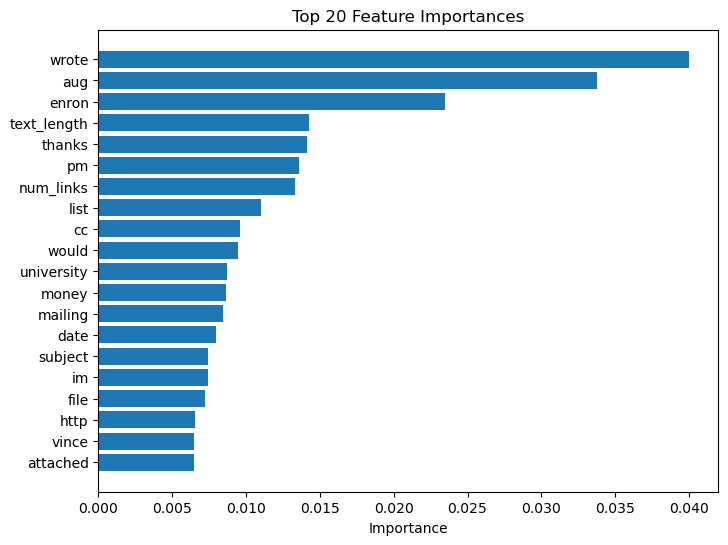

In [21]:
tfidf_names = vectorizer.get_feature_names_out()
extra_names = ["num_links", "num_exclamations", "num_uppercase", "text_length", "keyword_score"]

all_features = list(tfidf_names) + extra_names

# Get top 20 important features
indices = np.argsort(rf.feature_importances_)[-20:]

plt.figure(figsize=(8,6))
plt.barh(range(len(indices)), rf.feature_importances_[indices])
plt.yticks(range(len(indices)), [all_features[i] for i in indices])
plt.title("Top 20 Feature Importances")
plt.xlabel("Importance")
plt.show()

The feature importance plot shows that the model relies on a mix of textual, structural, and contextual features to classify emails. Words such as “wrote”, “aug”, and “enron” are among the most influential, indicating that certain dataset-specific patterns strongly impact classification. Additionally, structural features like “text_length” and “num_links” play a significant role, confirming that phishing emails often differ in length and contain more links. Overall, the model captures both linguistic patterns and behavioral characteristics of emails.

## Interactive Email Classification System

A chatbot-style interface was implemented to simulate real-world interaction with the phishing detection system. The user provides an email message as input, which is processed using the same preprocessing and feature extraction pipeline applied during model training. The system then uses the trained Random Forest model to classify the email as either phishing or legitimate.

In [22]:
def predict_email(email_text):
    cleaned = clean_text(email_text)

    text_features = vectorizer.transform([cleaned])

    num_links = email_text.count("http")
    num_exclamations = email_text.count("!")
    num_uppercase = sum(1 for c in email_text if c.isupper())
    text_length = len(email_text)
    keyword_score = keyword_count(email_text)

    extra_features = np.array([[num_links, num_exclamations, num_uppercase, text_length, keyword_score]])
    final_features = hstack([text_features, extra_features])

    prediction = rf.predict(final_features)[0]

    if prediction == 1:
        return "This email is classified as PHISHING."
    else:
        return "This email is classified as LEGITIMATE."

In [23]:
examples = [
    """
    Hi John,
    Please find attached the meeting notes from yesterday.
    Let me know if you have any comments.
    Thanks.
    """,

    """
    URGENT! Your bank account has been locked.
    Click here immediately to verify your password:
    http://secure-bank-update-login.com
    """,

    """
    Dear customer, you have won a reward.
    To claim your prize, enter your login and card details here:
    http://claim-free-gift.com
    """,

    """
    Hello team,
    The project update meeting is scheduled for 3 PM today.
    Best regards.
    """,

    """
    Your mailbox storage is full.
    Confirm your account now or your email access will be disabled:
    http://mail-security-check.com
    """
]

for i, email in enumerate(examples, 1):
    result = predict_email(email)
    print(f"Example {i}:")
    print(result)
    print("-" * 50)

Example 1:
This email is classified as LEGITIMATE.
--------------------------------------------------
Example 2:
This email is classified as PHISHING.
--------------------------------------------------
Example 3:
This email is classified as PHISHING.
--------------------------------------------------
Example 4:
This email is classified as LEGITIMATE.
--------------------------------------------------
Example 5:
This email is classified as PHISHING.
--------------------------------------------------


In [24]:
while True:
    print("\nChatbot: Please paste your email below.")
    
    email = input("You: ")
    
    if email.lower() == "exit":
        print("Chatbot: Goodbye!")
        break
    
    result = predict_email(email)
    
    print(f"Chatbot: {result}")


Chatbot: Please paste your email below.


You:      Your mailbox storage is full.     Confirm your account now or your email access will be disabled:     http://mail-security-check.com


Chatbot: This email is classified as PHISHING.

Chatbot: Please paste your email below.


You:      Hello team,     The project update meeting is scheduled for 3 PM today.     Best regards.


Chatbot: This email is classified as LEGITIMATE.

Chatbot: Please paste your email below.


You:  exit


Chatbot: Goodbye!
